In [7]:
%pip install torch torchvision numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [5]:
# define transformations
transform_no_norm = transforms.Compose([
    transforms.ToTensor()
])

# download MNIST dataset to calculate mean and std
train_dataset_og = datasets.MNIST(root = './data', train = True, download = True, transform = transform_no_norm)
train_loader_og = DataLoader(train_dataset_og, batch_size = 64, shuffle = False)

# calculate the mean and std to normalize
mean = 0.0
std = 0.0
total_images = 0

for images, im in train_loader_og: # go through all the images in the loader by batches
    batch_samples = images.size(0) # batch size by size(0)
    images = images.view(batch_samples, images.size(1), -1) # basically reorganizing the tensor (?) to [batch, channels, pizels]
    mean += images.mean(2).sum(0) # 2 is the pixels, 0 is the 64 images in the batch
    std += images.std(2).sum(0)
    total_images += batch_samples # calc mean and std with all images not batches

mean /= total_images
std /= total_images

# define transformations with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean.item(),), (std.item(),))
])

# reload datasets with normalization
train_dataset = datasets.MNIST(root = './data', train = True, download = False, transform = transform)
test_dataset = datasets.MNIST(root = './data', train = False, download = False, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

100.0%
100.0%
100.0%
100.0%


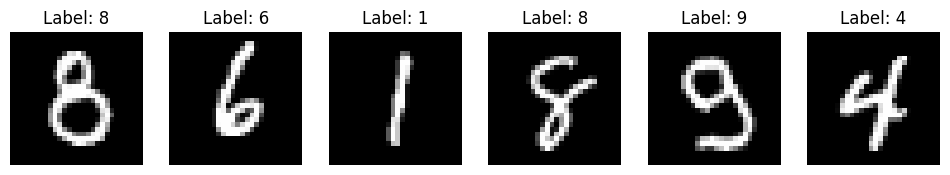

In [6]:
# visualize the data

# get one batch
examples = iter(train_loader) # converts the dataloader into an iterator
images, labels = next(examples) # get the first batch from the iterator

# create sublpots
fig, axes = plt.subplots(1, 6, figsize =(12, 2))
# creates a figure with 1 row and 6 columns 
# figsize=12,2 sets the size: 12 in wide, 2 in tall

# loop through and display images
for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap = 'gray') # squeeze removes dimensions
    axes[i].set_title(f'Label: {labels[i]}')
    axes[i].axis('off')
plt.show()

In [8]:
# build the CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 3, padding =1) # padding bc the img shrinks gradually (bigger kernel size needs more padding)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
        
        # pooling layer
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)

        # dropout = randomly sets some neurons to 0 to prevent overfitting
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        # fully connected layers connect input neurons to output
        self.fc1 = nn.Linear(64 * 7 * 7, 128) # flattening
        self.fc2 = nn.Linear(128, 10) # 10 is to make the final digit prediction

    def forward(self, x):
        # first conv block
        x = self.conv1(x) # apply convolution
        x = torch.relu(x) # activation function
        x = self.pool(x) # reduce from 28x28 -> 14x14

        x = self.conv2(x)
        x = torch.relu(x) # activation function
        x = self.pool(x) # reduce from 14x14 -> 7x7
        x = self.dropout1(x) # drop 25% of values

        # flatten for fully connected layers
        x = x.view(-1, 64 * 7 * 7)

        # fully conected layers
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)

        return x
    
model = CNN().to(torch.device('cpu'))

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer = updates model weights to reduce loss
optimizer = optim.Adam(model.parameters(), lr = 0.001) # adam = adaptive learning rate


In [14]:
# training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0 # cumulative sum of loss values of batches during an epoch
    correct = 0
    total = 0

    for images, labels in train_loader:
        # move data to device
        images, labels = images.to(device), labels.to(device)

        # reset gradients (how much to change each weight to reduce loss)
        optimizer.zero_grad()

        # forward pass: make predictions
        outputs = model(images)

        # calculate loss
        loss = criterion(outputs, labels)

        # backward pass: calculate gradients
        loss.backward()

        # update weights
        optimizer.step()

        # track accuracy
        _, predicted = torch.max(outputs.data, 1) # finds the max value and its index for dineension 1
        total += labels.size(0)
        correct += (predicted == labels).sum().item() #.item() converst to python number
        running_loss += loss.item()
    
    epoch_loss = running_loss/ len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


In [ ]:
# evaluation function
def evaluate(model, test_loader, criterion, device):
    model.eval() 

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # dont calculate gradients to save memory (inference mode)
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            running_loss += loss.item()

    test_loss = running_loss / len(test_loader)
    test_acc = 100* correct / total

    return test_loss, test_acc

In [16]:
# train the model
num_epochs = 5
for epoch in range(num_epochs):
    print(f"epoch {epoch + 1}")

    # train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, torch.device('cpu'))

    # evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, torch.device('cpu'))

    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

epoch 1
Train Loss: 0.2069, Train Acc: 93.60%
Test Loss: 0.0437, Test Acc: 98.57%
epoch 2
Train Loss: 0.0865, Train Acc: 97.41%
Test Loss: 0.0390, Test Acc: 98.76%
epoch 3
Train Loss: 0.0660, Train Acc: 97.96%
Test Loss: 0.0298, Test Acc: 99.00%
epoch 4
Train Loss: 0.0568, Train Acc: 98.28%
Test Loss: 0.0262, Test Acc: 99.21%
epoch 5
Train Loss: 0.0490, Train Acc: 98.52%
Test Loss: 0.0219, Test Acc: 99.21%


In [24]:
# make predictions
def predict_digit(model, image, device):
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device) # add batch dimension bc model requires input
        output = model(image)
        _, predicted = torch.max(output, 1)
        probabilities = torch.nn.functional.softmax(output, dim = 1)
        confidence = probabilities[0][predicted].item() * 100
    return predicted.item(), confidence

# test on one image
test_image, test_label = test_dataset[0]
prediction, confidence = predict_digit(model, test_image, torch.device('cpu'))

print(f"Actual label: {test_label}")
print(f"Predicted: {prediction} (confidence: {confidence:.1f}%)")


Actual label: 7
Predicted: 7 (confidence: 100.0%)
